In [4]:
#Load the Airbnb Dataset
import pandas as pd

df = pd.read_csv("listings.csv")

df.head()

,id,name,host_id,host_profile_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,2992450,Luxury 2 bedroom apartment,4621559,1462661762635155041,Kenneth,NaN,THIRD WARD,42.65789,-73.75370,Entire home/apt,80.0,28.0,9,2022-08-17,0.06,1,77,0,NaN
1,3820211,Restored Precinct in Center Sq. w/Parking,19648678,1463087024016718788,Ming,NaN,SIXTH WARD,42.65222,-73.76724,Entire home/apt,211.0,1.0,317,2026-01-25,2.20,7,328,8,NaN
2,5651579,Large studio apt by Capital Center & ESP@,29288920,1465431505328745177,Gregg,NaN,SECOND WARD,42.64615,-73.75966,Entire home/apt,97.0,1.0,406,2026-06-12,3.00,2,25,37,NaN
3,6623339,Center Sq. Loft in Converted Precinct w/ Parking,19648678,1463087024016718788,Ming,NaN,SIXTH WARD,42.65222,-73.76724,Entire home/apt,160.0,1.0,332,2025-06-30,2.47,7,359,1,NaN
4,9501054,Spacious suite with full bath by Capital Center,29288920,1465431505328745177,Gregg,NaN,SECOND WARD,42.64734,-73.75851,Private room,86.0,1.0,469,2026-06-09,3.71,2,235,47,NaN


In [55]:
#Check Dataset Dimensions
df.shape

(490, 17)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              490 non-null    int64  
 1   name                            490 non-null    object 
 2   host_id                         490 non-null    int64  
 3   host_profile_id                 490 non-null    int64  
 4   host_name                       490 non-null    object 
 5   neighbourhood_group             0 non-null      float64
 6   neighbourhood                   490 non-null    object 
 7   latitude                        490 non-null    float64
 8   longitude                       490 non-null    float64
 9   room_type                       490 non-null    object 
 10  price                           458 non-null    float64
 11  minimum_nights                  489 non-null    float64
 12  number_of_reviews               490 

In [7]:
#Inspect Dataset Structure
df.isnull().sum()

,0
id,0
name,0
host_id,0
host_profile_id,0
host_name,0
neighbourhood_group,490
neighbourhood,0
latitude,0
longitude,0
room_type,0


In [8]:
#Inspect Dataset Structure
df.duplicated().sum()

np.int64(0)

In [9]:
# Check columns that are completely empty
df.isna().all()

,0
id,False
name,False
host_id,False
host_profile_id,False
host_name,False
neighbourhood_group,True
neighbourhood,False
latitude,False
longitude,False
room_type,False


In [10]:
# Remove completely empty columns
df = df.dropna(axis=1, how='all')

df.shape

(490, 17)

In [11]:
df.isnull().sum().sort_values(ascending=False)

,0
reviews_per_month,60
last_review,60
price,32
minimum_nights,1
id,0
name,0
host_id,0
host_profile_id,0
host_name,0
room_type,0


In [12]:
#statistics of the data
df['price'].describe()

,price
count,458.000000
mean,177.176856
std,157.372995
min,13.000000
25%,90.000000
50%,145.500000
75%,209.750000
max,1701.000000


In [56]:
#cleaned dataset
df[df['price'].isna()][['id', 'name', 'neighbourhood', 'room_type', 'price']]

,id,name,neighbourhood,room_type,price


In [14]:
df[df['minimum_nights'].isna()]

,id,name,host_id,host_profile_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
58,43736299,*The Blue House* Incredible 3 Bedroom Apartment,349460842,1469695254081708328,Scott,TENTH WARD,42.66257,-73.78281,Entire home/apt,NaN,NaN,131,2024-10-28,1.8,21,0,0


In [15]:
# Check missing-value patterns

print("PRICE MISSING:")
print(df[df['price'].isna()][
    ['room_type', 'neighbourhood', 'number_of_reviews', 'availability_365']
].head(10))

print("\nMINIMUM NIGHTS MISSING:")
print(df[df['minimum_nights'].isna()][
    ['room_type', 'neighbourhood', 'price']
])

print("\nREVIEWS PER MONTH MISSING:")
print(df[df['reviews_per_month'].isna()][
    ['number_of_reviews', 'last_review', 'room_type']
].head(10))

PRICE MISSING:
           room_type    neighbourhood  number_of_reviews  availability_365
26      Private room    ELEVENTH WARD                 36                17
40      Private room      EIGHTH WARD                220                 0
58   Entire home/apt       TENTH WARD                131                 0
101  Entire home/apt      FOURTH WARD                  3               365
105  Entire home/apt       SIXTH WARD                266                 0
116  Entire home/apt       SIXTH WARD                103                 0
121  Entire home/apt      SECOND WARD                 28                 0
150  Entire home/apt  FOURTEENTH WARD                  7                 2
183  Entire home/apt  THIRTEENTH WARD                 96                 0
201  Entire home/apt       FIRST WARD                 14                 0

MINIMUM NIGHTS MISSING:
          room_type neighbourhood  price
58  Entire home/apt    TENTH WARD    NaN

REVIEWS PER MONTH MISSING:
     number_of_reviews la

In [16]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [17]:
df['last_review'] = pd.to_datetime(
    df['last_review'],
    errors='coerce'
)

In [18]:
df['minimum_nights'] = df['minimum_nights'].fillna(
    df['minimum_nights'].median()
)

In [19]:
df['price'] = df.groupby('room_type')['price'].transform(
    lambda x: x.fillna(x.median())
)

In [20]:
df.isnull().sum().sort_values(ascending=False)

,0
last_review,60
id,0
name,0
host_profile_id,0
host_id,0
neighbourhood,0
latitude,0
longitude,0
host_name,0
room_type,0


In [21]:
df.dtypes

,0
id,int64
name,object
host_id,int64
host_profile_id,int64
host_name,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


In [22]:
print("PRICE:")
print(df['price'].min(), df['price'].max())

print("\nMINIMUM NIGHTS:")
print(df['minimum_nights'].min(), df['minimum_nights'].max())

print("\nAVAILABILITY:")
print(df['availability_365'].min(), df['availability_365'].max())

print("\nNUMBER OF REVIEWS:")
print(df['number_of_reviews'].min(), df['number_of_reviews'].max())

print("\nREVIEWS PER MONTH:")
print(df['reviews_per_month'].min(), df['reviews_per_month'].max())

PRICE:
13.0 1701.0

MINIMUM NIGHTS:
1.0 365.0

AVAILABILITY:
0 365

NUMBER OF REVIEWS:
0 996

REVIEWS PER MONTH:
0.0 10.43


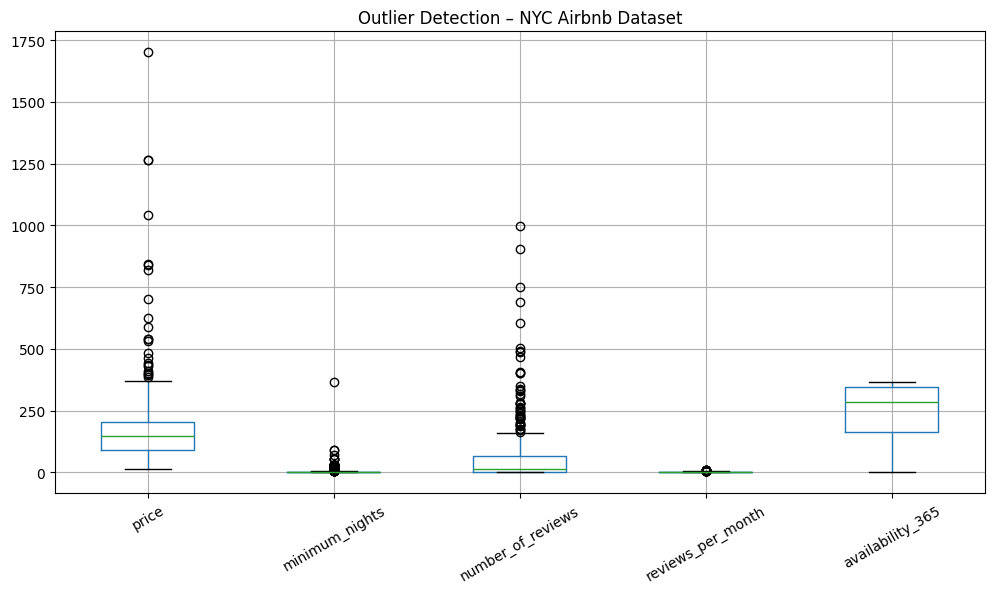

In [23]:
import matplotlib.pyplot as plt

df[['price', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'availability_365']].boxplot(
    figsize=(12, 6)
)

plt.xticks(rotation=30)
plt.title("Outlier Detection – NYC Airbnb Dataset")
plt.show()

In [24]:
print("Rows and columns:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique room types:")
print(df['room_type'].unique())

print("\nUnique neighbourhoods:", df['neighbourhood'].nunique())

Rows and columns: (490, 17)

Missing values:
id                                 0
name                               0
host_id                            0
host_profile_id                    0
host_name                          0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                       60
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
number_of_reviews_ltm              0
dtype: int64

Duplicate rows: 0

Unique room types:
['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']

Unique neighbourhoods: 15


In [25]:
df.to_csv("NYC_Airbnb_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final shape:", df.shape)

Cleaned dataset saved successfully!
Final shape: (490, 17)


In [26]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,490.0,NaN,NaN,NaN,961754887763929984.0,2992450.0,690491482540526848.0,1112066972991066112.0,1458294607708536064.0,1701482737257369600.0,580083733193505536.0
name,490,489,Large Bedroom in the heart of downtown Albany.,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,490.0,NaN,NaN,NaN,6840568713538563.0,649068.0,47625981.0,232967878.0,466790114.0,1676922675439893504.0,106962314407833600.0
host_profile_id,490.0,NaN,NaN,NaN,1472998320032593920.0,1462517583121314560.0,1463574448322349056.0,1468231973425237504.0,1469754210102694656.0,1676923224672492288.0,28192492503188136.0
host_name,490,169,⁨Premier Stay Co.⁩,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,490,15,SIXTH WARD,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,490.0,NaN,NaN,NaN,42.658781,42.63066,42.652777,42.657355,42.664338,42.7149,0.010441
longitude,490.0,NaN,NaN,NaN,-73.776774,-73.87649,-73.787773,-73.774617,-73.764138,-73.73825,0.01819
room_type,490,4,Entire home/apt,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,490.0,NaN,NaN,NaN,174.953061,13.0,90.0,149.0,205.5,1701.0,152.733819


In [27]:
df[['room_type', 'neighbourhood']].describe()

,room_type,neighbourhood
count,490,490
unique,4,15
top,Entire home/apt,SIXTH WARD
freq,345,117


In [28]:
room_counts = df['room_type'].value_counts()

print(room_counts)

room_type
Entire home/apt    345
Private room       135
Hotel room           9
Shared room          1
Name: count, dtype: int64


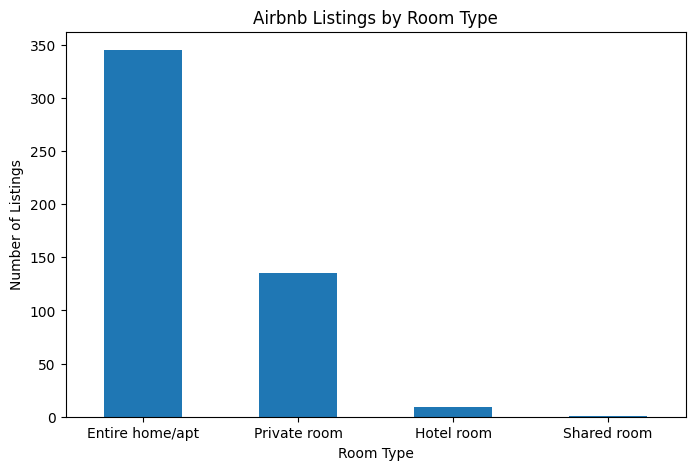

In [29]:
room_counts.plot(
    kind='bar',
    figsize=(8,5),
    title='Airbnb Listings by Room Type'
)

plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.show()

In [30]:
price_by_room = df.groupby('room_type')['price'].agg(
    ['count', 'mean', 'median', 'min', 'max']
).sort_values('mean', ascending=False)

price_by_room

,count,mean,median,min,max
room_type,,,,,
Shared room,1,840.000000,840.0,840.0,840.0
Hotel room,9,213.555556,186.0,124.0,372.0
Entire home/apt,345,205.701449,166.0,73.0,1701.0
Private room,135,88.874074,72.0,13.0,331.0


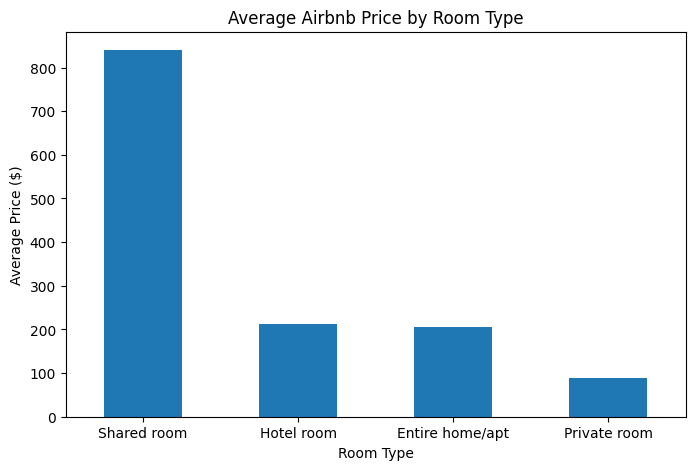

In [31]:
price_by_room['mean'].plot(
    kind='bar',
    figsize=(8,5),
    title='Average Airbnb Price by Room Type'
)

plt.xlabel('Room Type')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.show()

In [32]:
neighbourhood_counts = df['neighbourhood'].value_counts()

print(neighbourhood_counts.head(15))

neighbourhood
SIXTH WARD         117
TENTH WARD          56
THIRD WARD          43
NINTH WARD          42
SECOND WARD         41
THIRTEENTH WARD     41
FOURTEENTH WARD     32
ELEVENTH WARD       32
FOURTH WARD         15
FIFTEENTH WARD      14
FIFTH WARD          14
SEVENTH WARD        14
EIGHTH WARD         13
FIRST WARD          12
TWELFTH WARD         4
Name: count, dtype: int64


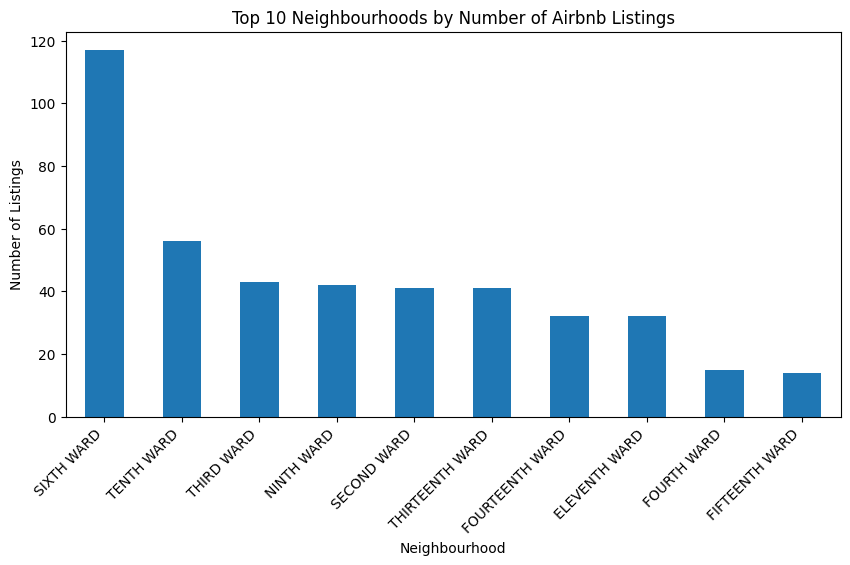

In [33]:
neighbourhood_counts.head(10).plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Neighbourhoods by Number of Airbnb Listings'
)

plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.show()

In [34]:
neighbourhood_price = df.groupby('neighbourhood')['price'].agg(
    ['count', 'mean', 'median']
)

# Keep neighbourhoods with at least 5 listings
neighbourhood_price = neighbourhood_price[
    neighbourhood_price['count'] >= 5
].sort_values('mean', ascending=False)

neighbourhood_price.head(10)

,count,mean,median
neighbourhood,,,
FIFTEENTH WARD,14,346.357143,295.0
SEVENTH WARD,14,233.428571,205.0
EIGHTH WARD,13,232.153846,209.0
SECOND WARD,41,222.243902,180.0
FIRST WARD,12,218.250000,186.0
FOURTH WARD,15,204.733333,195.0
FOURTEENTH WARD,32,194.125000,105.0
THIRTEENTH WARD,41,182.195122,124.0
SIXTH WARD,117,163.863248,161.0


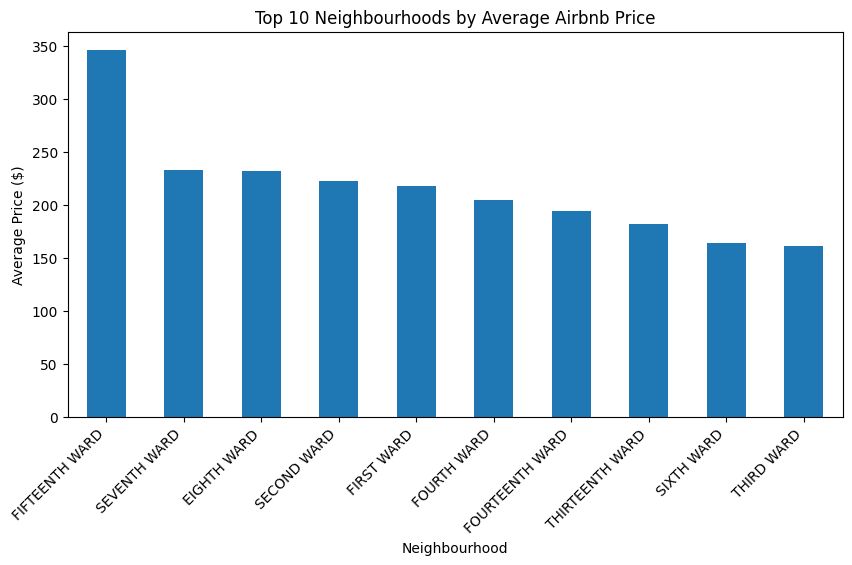

In [35]:
neighbourhood_price.head(10)['mean'].plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Neighbourhoods by Average Airbnb Price'
)

plt.xlabel('Neighbourhood')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [36]:
room_neighbourhood = pd.crosstab(
    df['neighbourhood'],
    df['room_type']
)

room_neighbourhood = room_neighbourhood.loc[
    neighbourhood_counts.head(10).index
]

room_neighbourhood

room_type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood,,,,
SIXTH WARD,99,0,18,0
TENTH WARD,21,0,35,0
THIRD WARD,30,8,5,0
NINTH WARD,20,0,21,1
SECOND WARD,37,0,4,0
THIRTEENTH WARD,20,0,21,0
FOURTEENTH WARD,19,0,13,0
ELEVENTH WARD,23,1,8,0
FOURTH WARD,13,0,2,0


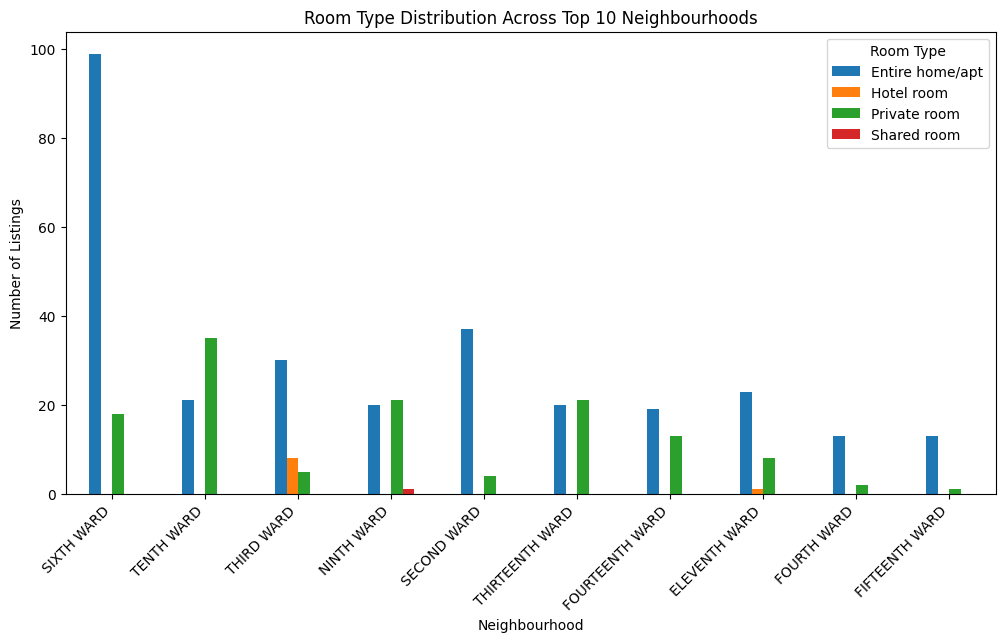

In [37]:
room_neighbourhood.plot(
    kind='bar',
    figsize=(12,6),
    title='Room Type Distribution Across Top 10 Neighbourhoods'
)

plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Room Type')
plt.show()

In [38]:
review_analysis = df.groupby('room_type').agg(
    total_reviews=('number_of_reviews', 'sum'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_reviews_per_month=('reviews_per_month', 'mean'),
    listings=('id', 'count')
).sort_values('total_reviews', ascending=False)

review_analysis

,total_reviews,avg_reviews,avg_reviews_per_month,listings
room_type,,,,
Entire home/apt,22471,65.133333,1.817072,345
Private room,6564,48.622222,0.928444,135
Shared room,9,9.000000,0.260000,1
Hotel room,2,0.222222,0.020000,9


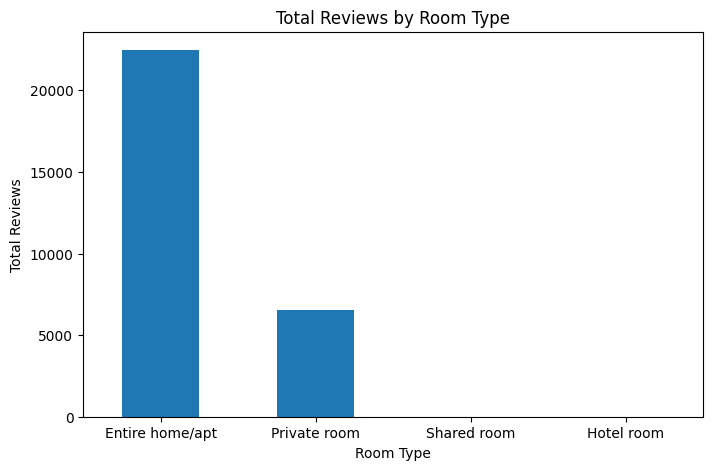

In [39]:
review_analysis['total_reviews'].plot(
    kind='bar',
    figsize=(8,5),
    title='Total Reviews by Room Type'
)

plt.xlabel('Room Type')
plt.ylabel('Total Reviews')
plt.xticks(rotation=0)
plt.show()

In [40]:
availability_analysis = df.groupby('room_type').agg(
    avg_availability=('availability_365', 'mean'),
    avg_reviews_per_month=('reviews_per_month', 'mean'),
    avg_total_reviews=('number_of_reviews', 'mean'),
    listings=('id', 'count')
).sort_values('avg_reviews_per_month', ascending=False)

availability_analysis

,avg_availability,avg_reviews_per_month,avg_total_reviews,listings
room_type,,,,
Entire home/apt,252.860870,1.817072,65.133333,345
Private room,215.162963,0.928444,48.622222,135
Shared room,141.000000,0.260000,9.000000,1
Hotel room,288.111111,0.020000,0.222222,9


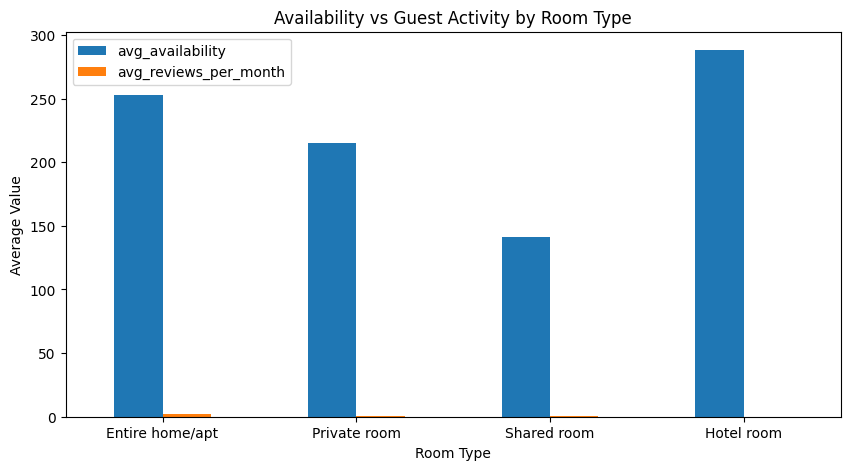

In [41]:
availability_analysis[['avg_availability', 'avg_reviews_per_month']].plot(
    kind='bar',
    figsize=(10,5),
    title='Availability vs Guest Activity by Room Type'
)

plt.xlabel('Room Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

In [42]:
price_demand = df.groupby('room_type').agg(
    avg_price=('price', 'mean'),
    avg_reviews_per_month=('reviews_per_month', 'mean'),
    avg_total_reviews=('number_of_reviews', 'mean'),
    listings=('id', 'count')
).sort_values('avg_price', ascending=False)

price_demand

,avg_price,avg_reviews_per_month,avg_total_reviews,listings
room_type,,,,
Shared room,840.000000,0.260000,9.000000,1
Hotel room,213.555556,0.020000,0.222222,9
Entire home/apt,205.701449,1.817072,65.133333,345
Private room,88.874074,0.928444,48.622222,135


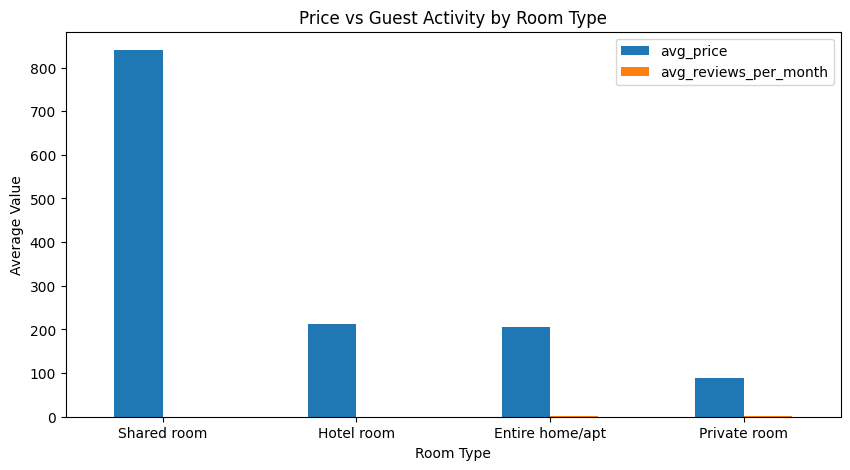

In [43]:
price_demand[['avg_price', 'avg_reviews_per_month']].plot(
    kind='bar',
    figsize=(10, 5),
    title='Price vs Guest Activity by Room Type'
)

plt.xlabel('Room Type')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.show()

In [44]:
host_analysis = df.groupby('host_id').agg(
    listings=('id', 'count'),
    avg_price=('price', 'mean'),
    avg_reviews=('number_of_reviews', 'mean'),
    avg_availability=('availability_365', 'mean')
).sort_values('listings', ascending=False)

host_analysis.head(10)

,listings,avg_price,avg_reviews,avg_availability
host_id,,,,
466790114,29,92.724138,6.896552,360.896552
349460842,21,103.142857,27.333333,266.380952
47625981,16,223.062500,71.125000,217.625000
37769478,16,172.375000,53.875000,326.437500
232967878,14,290.142857,92.071429,80.285714
20536619,13,90.384615,4.230769,62.153846
382970529,12,325.916667,87.250000,48.000000
44434571,11,232.454545,257.909091,329.181818
188679144,11,127.727273,13.727273,346.454545


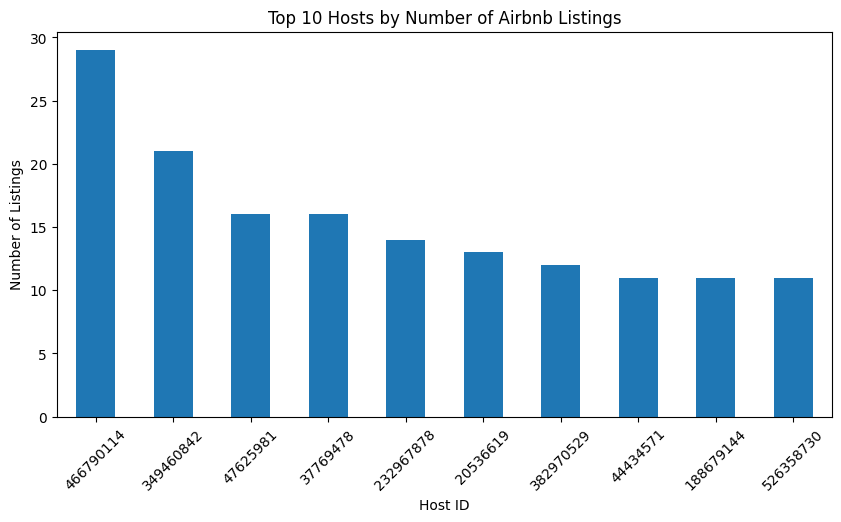

In [45]:
host_analysis.head(10)['listings'].plot(
    kind='bar',
    figsize=(10,5),
    title='Top 10 Hosts by Number of Airbnb Listings'
)

plt.xlabel('Host ID')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.show()

In [46]:
print("Total hosts:", df['host_id'].nunique())
print("Total listings:", len(df))
print("Average listings per host:", round(
    len(df) / df['host_id'].nunique(), 2
))

Total hosts: 186
Total listings: 490
Average listings per host: 2.63


In [47]:
top_listings = df[
    ['id', 'name', 'neighbourhood', 'room_type',
     'price', 'number_of_reviews', 'reviews_per_month']
].sort_values(
    'number_of_reviews',
    ascending=False
)

top_listings.head(10)

,id,name,neighbourhood,room_type,price,number_of_reviews,reviews_per_month
30,25549565,Quiet and Pretty in the Heart of Center Square,SIXTH WARD,Entire home/apt,115.0,996,10.20
5,10768745,Alb hospital area studio bath wifi. (Red),FOURTEENTH WARD,Private room,58.0,906,7.18
35,28722270,Historic Loft Suite @ Downtown Albany,SECOND WARD,Entire home/apt,142.0,749,8.14
36,28868857,Cozy Garden 2-Bed Full Amenities @ Downtown Al...,SECOND WARD,Entire home/apt,119.0,692,7.57
13,16531782,On a little park in Albany pine hills. (Blue),FOURTEENTH WARD,Private room,92.0,604,8.20
43,33558235,"Historic, Spacious & Fun 2BR Apt @ Downtown Al...",SECOND WARD,Entire home/apt,186.0,505,5.79
47,38321579,Comfy and quiet,EIGHTH WARD,Private room,75.0,490,5.95
42,32993402,Historic Full Amenities 2BR Apt @Downtown Albany,SECOND WARD,Entire home/apt,188.0,488,5.53
4,9501054,Spacious suite with full bath by Capital Center,SECOND WARD,Private room,86.0,469,3.71
2,5651579,Large studio apt by Capital Center & ESP@,SECOND WARD,Entire home/apt,97.0,406,3.00


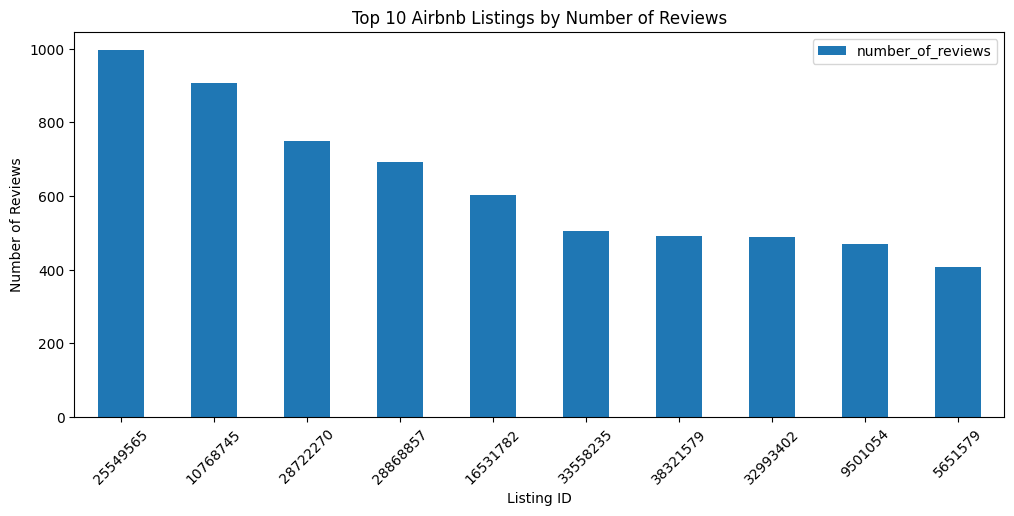

In [48]:
top_listings.head(10).plot(
    x='id',
    y='number_of_reviews',
    kind='bar',
    figsize=(12, 5),
    title='Top 10 Airbnb Listings by Number of Reviews'
)

plt.xlabel('Listing ID')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)
plt.show()

In [49]:
premium_listings = df[
    ['id', 'name', 'neighbourhood', 'room_type',
     'price', 'number_of_reviews', 'reviews_per_month']
].sort_values(
    'price',
    ascending=False
)

premium_listings.head(10)

,id,name,neighbourhood,room_type,price,number_of_reviews,reviews_per_month
113,621960198566758900,The Historic Jesse Buel Farmhouse,FOURTEENTH WARD,Entire home/apt,1701.0,18,0.38
117,638900897313146306,🪴 Historic & Homey 1 Bdrm Apt @ Downtown Albany,SECOND WARD,Entire home/apt,1267.0,10,0.20
220,1012862218478447339,ABBA House Retreat: Centrally Located Grand Manor,THIRTEENTH WARD,Entire home/apt,1265.0,11,1.76
78,48470454,"/ New Giant Victorian \ 7beds 6 baths + 2x 85""...",THIRTEENTH WARD,Entire home/apt,1041.0,67,1.41
24,21449583,/zBig Blue Ranch\ 1962 SUNY Eagle Hill 4Beds 2...,FIFTEENTH WARD,Entire home/apt,846.0,9,0.09
146,795541666227926706,Historic Washington Park Inn | Full Mansion | ...,NINTH WARD,Shared room,840.0,9,0.26
94,52691284,+ Perfect place to make memories with loved on...,TENTH WARD,Entire home/apt,819.0,113,1.99
100,53860077,/ Sauna Garden Getaway\ 1943 SUNY Eagle Hill,FIFTEENTH WARD,Entire home/apt,701.0,62,1.20
211,992554549672159765,5BR/4BA Retreat | Fire Pit + BBQ,SEVENTH WARD,Entire home/apt,625.0,24,0.84
162,845960193409947556,Modern Cottage-Perfect for Families!,FIRST WARD,Entire home/apt,587.0,160,4.07


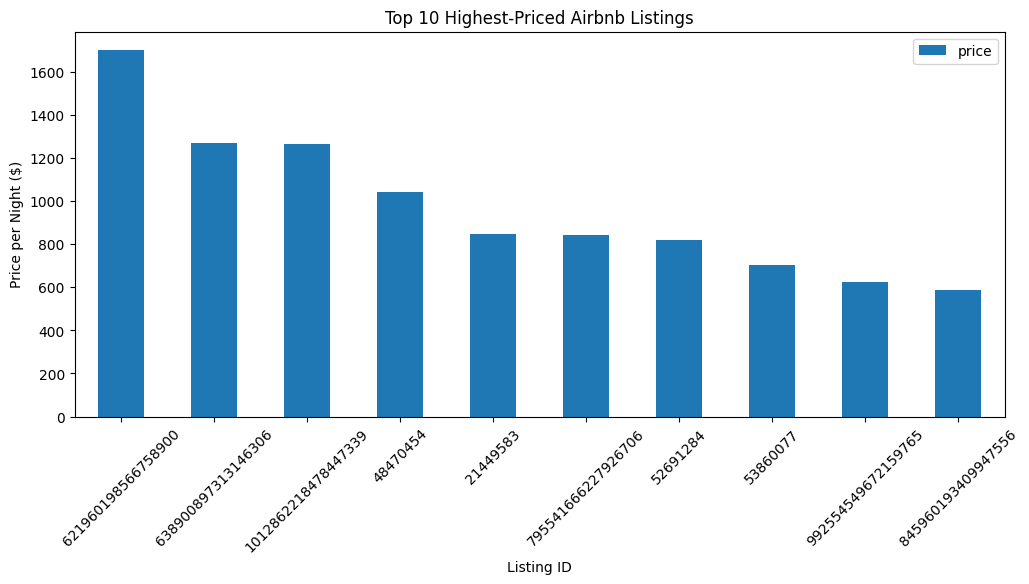

In [50]:
premium_listings.head(10).plot(
    x='id',
    y='price',
    kind='bar',
    figsize=(12, 5),
    title='Top 10 Highest-Priced Airbnb Listings'
)

plt.xlabel('Listing ID')
plt.ylabel('Price per Night ($)')
plt.xticks(rotation=45)
plt.show()

In [51]:
correlation = df[['price', 'number_of_reviews',
                  'reviews_per_month']].corr()

correlation

,price,number_of_reviews,reviews_per_month
price,1.000000,0.000885,0.066037
number_of_reviews,0.000885,1.000000,0.698444
reviews_per_month,0.066037,0.698444,1.000000


In [52]:
print(
    "Price vs Number of Reviews:",
    round(correlation.loc['price', 'number_of_reviews'], 2)
)

print(
    "Price vs Reviews per Month:",
    round(correlation.loc['price', 'reviews_per_month'], 2)
)

Price vs Number of Reviews: 0.0
Price vs Reviews per Month: 0.07


In [53]:
min_nights_analysis = df.groupby('room_type').agg(
    avg_minimum_nights=('minimum_nights', 'mean'),
    median_minimum_nights=('minimum_nights', 'median'),
    listings=('id', 'count')
).sort_values('avg_minimum_nights', ascending=False)

min_nights_analysis

,avg_minimum_nights,median_minimum_nights,listings
room_type,,,
Private room,11.592593,2.0,135
Entire home/apt,5.139130,1.0,345
Hotel room,1.000000,1.0,9
Shared room,1.000000,1.0,1


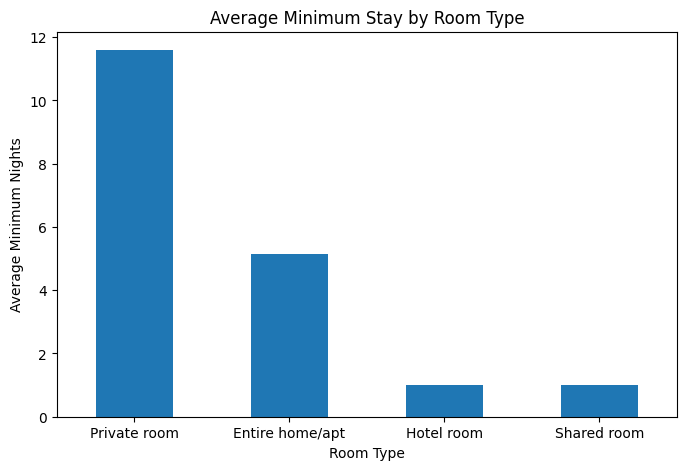

In [54]:
min_nights_analysis['avg_minimum_nights'].plot(
    kind='bar',
    figsize=(8, 5),
    title='Average Minimum Stay by Room Type'
)

plt.xlabel('Room Type')
plt.ylabel('Average Minimum Nights')
plt.xticks(rotation=0)
plt.show()